## ⚙️ Étape 1 — Installation & imports

> **HydroWatch — Détection d'anomalies eau · Échelles SONEDE 2023**
>
> Sources de calibration :
> - **SONEDE** — Rapport Annuel 2023 (consommations de référence, tranches tarifaires)
> - **INS Tunisie** — Consommation moyenne ménage : ~113 L/j → pic diurne ≈ 0.013 m³/h
> - **INRGREF** — Fuites domestiques observées : 50–300 L/nuit (2–12 L/h)
> - **Norme EN 806-3** — Dimensionnement installations intérieures eau sanitaire
> - **ONAS 2022** — Coefficients de foisonnement résidentiel collectif


In [1]:
# ✅ Kaggle version — pas besoin de Google Drive
# Les fichiers sont sauvegardés dans /kaggle/working/
import os
print("Working dir:", os.getcwd())
print("Output dir: /kaggle/working/")


Working dir: /kaggle/working
Output dir: /kaggle/working/


In [2]:
!pip install -q xgboost scikit-learn imbalanced-learn pandas numpy matplotlib seaborn
print('✅ Packages installés')


✅ Packages installés


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import json, os, joblib
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

np.random.seed(42)
print('✅ Imports OK')


✅ Imports OK


## 📊 Étape 2 — Génération du dataset

Données synthétiques calibrées sur les **normes tunisiennes SONEDE 2023** :

| Paramètre | Valeur | Source |
|-----------|--------|--------|
| Consommation maison (pic diurne) | **0.013 m³/h** | SONEDE 2023 / INS |
| Seuil d'alerte | **0.018 m³/h** ≡ 40 m³/trimestre | Tranche 2 SONEDE |
| Stress hydrique été | **×2.0** vs printemps | SONEDE 2023 |
| Fuite nocturne | **2–12 L/h** (persistante) | INRGREF Tunisie |
| Hiver | **×0.6** vs printemps | Courbe saisonnière SONEDE |


In [4]:
# ─────────────────────────────────────────────────────────────────────────
# PARAMÈTRES — Échelles réalistes SONEDE 2023 (Rapport annuel)
#
# Unités : m³/heure  (relevé compteur toutes les heures)
#
# Consommation domestique de référence (SONEDE 2023) :
#   Ménage tunisien moyen : ~113 L/j  →  ~0.0047 m³/h en continu
#   Pic diurne (cuisine + douche + WC) ≈ 0.013 m³/h
#   → BASE_MAISON = 0.013 m³/h (conforme au rapport SONEDE)
#
# Système de tranches SONEDE (tarification progressive) :
#   Tranche 1 :   0–40  m³/trimestre  →  usage domestique normal
#   Tranche 2 :  40–70  m³/trimestre  →  confort, seuil d'alerte = 40 m³/trim
#   Tranche 3 :  70–150 m³/trimestre  →  surconsommation
#   Tranche 4 :  > 150  m³/trimestre  →  anomalie grave
#
#   Seuil alerte = 40 m³/trimestre = 40/(91*24) ≈ 0.018 m³/h
#   (91 jours × 24 h = 2184 heures dans un trimestre)
#
# Fuites nocturnes :
#   Petite fuite robinet : ~50–200 L/nuit → 0.002–0.008 m³/h
#   Fuite canalisation persistante : 200–500 L/nuit → 0.008–0.021 m³/h
#
# Stress hydrique estival (SONEDE 2023) :
#   Consommation estivale ×2 vs hiver  (climatisation + arrosage + tourisme)
# ─────────────────────────────────────────────────────────────────────────

BUILDING_TYPES = ['maison', 'appartement', 'cafe', 'restaurant',
                  'hotel', 'immeuble', 'usine']
SEASONS        = ['hiver', 'printemps', 'ete', 'automne']

# Consommation normale de référence (m³/h) par type de local
# Basé sur : SONEDE 2023, norme EN 806-3, et données ONAS Tunisie
THRESHOLDS = {
    'maison'      : 0.013,   # ménage tunisien moyen (pic diurne ~0.013 m³/h)
    'appartement' : 0.009,   # surface plus petite, ~70% maison individuelle
    'cafe'         : 0.045,   # café tunisien : 50–80 couverts, forte rotation
    'restaurant'  : 0.090,   # restaurant : cuisine + salle, pic déjeuner/dîner
    'hotel'        : 0.250,   # hôtel 3★, 50 chambres, piscine incluse
    'immeuble'    : 0.120,   # immeuble 10 appartements (×0.009 × facteur foisonnement)
    'usine'        : 0.400,   # PME industrielle tunisienne, process + sanitaires
}

# Seuil d'alerte = équivalent 40 m³/trimestre pour maison
# → 40 m³ / 2184 h ≈ 0.018 m³/h ; on applique un ratio par type
# Ratio alerte : maison ×1.4, établissements ×1.3–1.5
ALERT_THRESHOLDS = {
    'maison'      : 0.018,   # 40 m³/trimestre SONEDE tranche 2
    'appartement' : 0.013,   # seuil ajusté surface
    'cafe'         : 0.065,   # ×1.45 du seuil normal
    'restaurant'  : 0.130,   # ×1.45
    'hotel'        : 0.375,   # ×1.50
    'immeuble'    : 0.175,   # ×1.46
    'usine'        : 0.600,   # ×1.50
}

# Coefficients saisonniers — stress hydrique tunisien (SONEDE 2023)
# Été ×2.0 : climatisation, arrosage jardins, forte demande touristique
# Hiver ×0.6 : faible demande, précipitations couvrent une partie des besoins
SEASON_COEF = {
    'hiver'    : 0.60,   # faible demande (déc–fév)
    'printemps': 1.00,   # référence
    'ete'      : 2.00,   # stress hydrique maximal (juin–août) — SONEDE 2023
    'automne'  : 0.85,   # retour progressif à la normale
}

# Ratio de consommation nocturne (22h–06h) — exprimé en fraction du seuil normal
# Fuites : petites (litres) mais persistantes toute la nuit
# Résidentiel quasi nul la nuit ; hôtel a du trafic 24h/24
NIGHT_RATIO = {
    'maison'      : 0.015,  # ~0.2 L/h résiduel (WC nocturne)
    'appartement' : 0.012,
    'cafe'         : 0.000,  # fermé la nuit
    'restaurant'  : 0.000,  # fermé la nuit
    'hotel'        : 0.120,  # service 24h/24 (réception, nuitards)
    'immeuble'    : 0.018,  # parties communes + quelques appartements
    'usine'        : 0.005,  # veille machine, nettoyage
}

# Paramètres des fuites nocturnes (m³/h)
# Source : INRGREF Tunisie — les fuites domestiques = 50–300 L/nuit
LEAK_MIN = 0.002   # ~2 L/h  (robinet qui goutte, joint usé)
LEAK_MAX = 0.012   # ~12 L/h (fissure canalisation, chasse WC défaillante)

ANOMALY_NAMES = {
    0: 'normal',
    1: 'surconsommation',
    2: 'fuite_nocturne',
    3: 'anomalie_saisonniere',
    4: 'conso_nulle',
    5: 'pic_inhabituel',
}
print('✅ Paramètres SONEDE 2023 définis')
print(f'   Maison référence    : {THRESHOLDS["maison"]:.3f} m³/h  (~{THRESHOLDS["maison"]*1000:.0f} L/h)')
print(f'   Alerte maison       : {ALERT_THRESHOLDS["maison"]:.3f} m³/h  (≡ 40 m³/trimestre SONEDE)')
print(f'   Fuite nocturne min  : {LEAK_MIN*1000:.0f} L/h  (robinet qui goutte)')
print(f'   Fuite nocturne max  : {LEAK_MAX*1000:.0f} L/h  (canalisation fissurée)')
print(f'   Coefficient été     : ×{SEASON_COEF["ete"]:.1f}  (stress hydrique SONEDE 2023)')


✅ Paramètres SONEDE 2023 définis
   Maison référence    : 0.013 m³/h  (~13 L/h)
   Alerte maison       : 0.018 m³/h  (≡ 40 m³/trimestre SONEDE)
   Fuite nocturne min  : 2 L/h  (robinet qui goutte)
   Fuite nocturne max  : 12 L/h  (canalisation fissurée)
   Coefficient été     : ×2.0  (stress hydrique SONEDE 2023)


In [5]:
# ─────────────────────────────────────────────────────────────────────────
# GÉNÉRATION DES DONNÉES — échelles réalistes SONEDE 2023
# ─────────────────────────────────────────────────────────────────────────
N = 4000
rows = []

# Historique glissant 7 jours initialisé à la consommation de référence
history = {b: [THRESHOLDS[b] * SEASON_COEF['printemps'] * 0.8
               for _ in range(7)]
           for b in BUILDING_TYPES}

for i in range(N):
    btype    = np.random.choice(BUILDING_TYPES)
    season   = np.random.choice(SEASONS)
    hour     = np.random.randint(0, 24)
    dow      = np.random.randint(0, 7)
    is_night = 1 if (hour >= 22 or hour <= 5) else 0

    thr   = THRESHOLDS[btype]
    alert = ALERT_THRESHOLDS[btype]
    coef  = SEASON_COEF[season]
    nratio= NIGHT_RATIO[btype]

    # ── Consommation normale ──────────────────────────────────────────────
    if is_night:
        # Nuit : quasi nul pour résidentiel, hôtel garde son activité
        normal_conso = thr * nratio * np.random.uniform(0.5, 1.5)
    else:
        # Jour : pic ×2 en été (stress hydrique tunisien SONEDE 2023)
        normal_conso = thr * coef * np.random.uniform(0.5, 1.1)

    # ── Tirage du type d'anomalie ─────────────────────────────────────────
    anomaly_type = np.random.choice(
        [0, 1, 2, 3, 4, 5],
        p=[0.58, 0.10, 0.10, 0.08, 0.07, 0.07]
    )

    if anomaly_type == 0:
        # Normal
        conso = normal_conso

    elif anomaly_type == 1:
        # Surconsommation : dépasse seuil d'alerte SONEDE (tranche 2+)
        conso = alert * np.random.uniform(1.1, 2.5)

    elif anomaly_type == 2:
        # Fuite nocturne : petite (litres) mais persistante
        # Plage de nuit forcée ; amplitude = LEAK_MIN à LEAK_MAX (m³/h)
        is_night = 1
        hour = np.random.choice(list(range(22, 24)) + list(range(0, 6)))
        # La fuite s'ajoute à la consommation résiduelle nocturne
        residuel = thr * nratio * np.random.uniform(0.5, 1.0)
        fuite    = np.random.uniform(LEAK_MIN, LEAK_MAX)
        conso    = residuel + fuite

    elif anomaly_type == 3:
        # Anomalie saisonnière : comportement d'été en hiver (ou vice versa)
        wrong_coef = SEASON_COEF['ete'] if season in ['hiver', 'automne']                      else SEASON_COEF['hiver']
        conso = thr * wrong_coef * np.random.uniform(1.2, 2.0)

    elif anomaly_type == 4:
        # Consommation nulle : compteur bloqué ou coupure
        conso = np.random.uniform(0.0, thr * 0.005)   # < 0.5% du seuil

    elif anomaly_type == 5:
        # Pic inhabituel : rupture de canalisation ou usage industriel illicite
        conso = alert * np.random.uniform(2.5, 5.0)

    # ── Features dérivées ────────────────────────────────────────────────
    hist_vals      = history[btype]
    rolling_avg_7d = np.mean(hist_vals)
    delta_vs_prev  = conso - hist_vals[-1]
    ratio_vs_hist  = conso / rolling_avg_7d if rolling_avg_7d > 0 else 0
    history[btype] = hist_vals[1:] + [conso]

    consumption_ratio = conso / thr if thr > 0 else 0

    # over_alert : dépasse le seuil tranche-2 SONEDE (40 m³/trimestre équivalent)
    over_alert  = 1 if conso > alert else 0

    # near_zero : compteur suspect (bloqué ou coupure réseau)
    near_zero   = 1 if conso < thr * 0.005 else 0

    # night_spike : flux nocturne anormal — seuil calibré sur LEAK_MAX
    # On déclenche si consommation nocturne > 1.5× fuite max connue
    night_spike = 1 if (is_night == 1 and conso > LEAK_MAX * 1.5) else 0

    rows.append({
        'building_type'      : btype,
        'season'             : season,
        'hour'               : hour,
        'day_of_week'        : dow,
        'is_night'           : is_night,
        'threshold_m3h'      : round(thr, 5),
        'alert_threshold_m3h': round(alert, 5),
        'consumption_m3h'    : round(conso, 5),
        'consumption_ratio'  : round(consumption_ratio, 4),
        'rolling_avg_7d'     : round(rolling_avg_7d, 5),
        'delta_vs_prev'      : round(delta_vs_prev, 5),
        'ratio_vs_history'   : round(ratio_vs_hist, 4),
        'over_alert'         : over_alert,
        'near_zero'          : near_zero,
        'night_spike'        : night_spike,
        'anomaly_label'      : anomaly_type,
        'anomaly_name'       : ANOMALY_NAMES[anomaly_type],
    })

df = pd.DataFrame(rows)

print(f'✅ Dataset généré : {len(df)} lignes × {df.shape[1]} colonnes')
print(f'\nDistribution des anomalies :')
print(df['anomaly_name'].value_counts().to_string())
print(f'\nStatistiques consommation (m³/h) :')
stats = df.groupby('building_type')['consumption_m3h'].agg(['mean','min','max'])
stats['mean_L/h'] = (stats['mean']*1000).round(1)
print(stats.round(5).to_string())
print(f'\nMaison — normal diurne (été) ≈ {df[(df.building_type=="maison")&(df.anomaly_name=="normal")&(df.season=="ete")&(df.is_night==0)]["consumption_m3h"].mean():.4f} m³/h')
print(f'Maison — fuite nocturne moyenne ≈ {df[(df.building_type=="maison")&(df.anomaly_name=="fuite_nocturne")]["consumption_m3h"].mean()*1000:.1f} L/h')


✅ Dataset généré : 4000 lignes × 17 colonnes

Distribution des anomalies :
anomaly_name
normal                  2255
surconsommation          422
fuite_nocturne           421
anomalie_saisonniere     330
pic_inhabituel           290
conso_nulle              282

Statistiques consommation (m³/h) :
                  mean      min      max  mean_L/h
building_type                                     
appartement    0.01112  0.00000  0.06418      11.1
cafe           0.05313  0.00000  0.32422      53.1
hotel          0.30758  0.00001  1.85086     307.6
immeuble       0.13969  0.00003  0.85392     139.7
maison         0.01424  0.00000  0.08577      14.2
restaurant     0.10134  0.00000  0.64027     101.3
usine          0.54220  0.00004  2.92377     542.2

Maison — normal diurne (été) ≈ 0.0197 m³/h
Maison — fuite nocturne moyenne ≈ 6.7 L/h


## 👁️ Étape 3 — Visualisation du dataset

In [6]:
# ─── Aperçu du dataset ────────────────────────────────────────
print('═'*70)
print('APERÇU DU DATASET — Échelles SONEDE 2023'.center(70))
print('═'*70)
print(f'  Lignes    : {len(df)}')
print(f'  Colonnes  : {df.shape[1]}')
print(f'  Mémoire   : {df.memory_usage(deep=True).sum() / 1024:.1f} KB')
print(f'  Unité     : m³/heure (relevé compteur horaire)')
print(f'  Maison normal (printemps) : ~{THRESHOLDS["maison"]:.3f} m³/h ({THRESHOLDS["maison"]*1000:.0f} L/h)')
print(f'  Maison normal (été ×2.0)  : ~{THRESHOLDS["maison"]*SEASON_COEF["ete"]:.3f} m³/h ({THRESHOLDS["maison"]*SEASON_COEF["ete"]*1000:.0f} L/h)')
print(f'  Seuil alerte maison       : {ALERT_THRESHOLDS["maison"]:.3f} m³/h ≡ 40 m³/trimestre')
df.head(10)


══════════════════════════════════════════════════════════════════════
               APERÇU DU DATASET — Échelles SONEDE 2023               
══════════════════════════════════════════════════════════════════════
  Lignes    : 4000
  Colonnes  : 17
  Mémoire   : 1288.8 KB
  Unité     : m³/heure (relevé compteur horaire)
  Maison normal (printemps) : ~0.013 m³/h (13 L/h)
  Maison normal (été ×2.0)  : ~0.026 m³/h (26 L/h)
  Seuil alerte maison       : 0.018 m³/h ≡ 40 m³/trimestre


,building_type,season,hour,day_of_week,is_night,threshold_m3h,alert_threshold_m3h,consumption_m3h,consumption_ratio,rolling_avg_7d,delta_vs_prev,ratio_vs_history,over_alert,near_zero,night_spike,anomaly_label,anomaly_name
0,usine,automne,14,2,0,0.40,0.600,1.03450,2.5862,0.32000,0.71450,3.2328,1,0,0,1,surconsommation
1,usine,ete,3,4,1,0.40,0.600,0.01028,0.0257,0.42207,-1.02422,0.0243,0,0,0,2,fuite_nocturne
2,immeuble,printemps,1,3,1,0.12,0.175,0.00148,0.0123,0.09600,-0.09452,0.0154,0,0,0,0,normal
3,immeuble,hiver,11,0,0,0.12,0.175,0.22668,1.8890,0.08250,0.22520,2.7477,1,0,0,1,surconsommation
4,restaurant,automne,15,6,0,0.09,0.130,0.24475,2.7195,0.07200,0.17275,3.3993,1,0,0,3,anomalie_saisonniere
5,usine,automne,2,4,1,0.40,0.600,0.00222,0.0055,0.37783,-0.00806,0.0059,0,0,0,0,normal
6,usine,printemps,3,0,1,0.40,0.600,0.34649,0.8662,0.33243,0.34427,1.0423,0,0,1,3,anomalie_saisonniere
7,hotel,printemps,19,3,0,0.25,0.375,0.19102,0.7641,0.20000,-0.00898,0.9551,0,0,0,0,normal
8,hotel,automne,14,2,0,0.25,0.375,0.22219,0.8888,0.19872,0.03117,1.1181,0,0,0,0,normal
9,restaurant,printemps,5,5,1,0.09,0.130,0.00000,0.0000,0.09668,-0.24475,0.0000,0,1,0,0,normal


In [7]:
# ─── Statistiques descriptives ────────────────────────────────
df.describe().round(3)


,hour,day_of_week,is_night,threshold_m3h,alert_threshold_m3h,consumption_m3h,consumption_ratio,rolling_avg_7d,delta_vs_prev,ratio_vs_history,over_alert,near_zero,night_spike,anomaly_label
count,4000.000,4000.000,4000.000,4000.000,4000.000,4000.000,4000.000,4000.000,4000.000,4000.000,4000.000,4000.000,4000.000,4000.000
mean,11.096,3.026,0.399,0.133,0.197,0.167,1.197,0.167,0.000,1.362,0.274,0.132,0.124,1.208
std,7.228,2.007,0.490,0.132,0.199,0.361,1.532,0.211,0.448,2.456,0.446,0.339,0.330,1.659
min,0.000,0.000,0.000,0.009,0.013,0.000,0.000,0.001,-2.920,0.000,0.000,0.000,0.000,0.000
25%,4.000,1.000,0.000,0.013,0.018,0.004,0.062,0.019,-0.058,0.049,0.000,0.000,0.000,0.000
50%,11.000,3.000,0.000,0.090,0.130,0.029,0.643,0.088,0.000,0.580,0.000,0.000,0.000,0.000
75%,17.250,5.000,1.000,0.250,0.375,0.161,1.679,0.211,0.058,1.567,1.000,0.000,0.000,2.000
max,23.000,6.000,1.000,0.400,0.600,2.924,7.403,1.363,2.828,55.714,1.000,1.000,1.000,5.000


In [8]:
# ─── Valeurs manquantes ───────────────────────────────────────
missing = df.isnull().sum()
print('Valeurs manquantes :', missing.sum(), '← doit être 0')
print(missing[missing > 0] if missing.sum() > 0 else '  Aucune ✅')


Valeurs manquantes : 0 ← doit être 0
  Aucune ✅


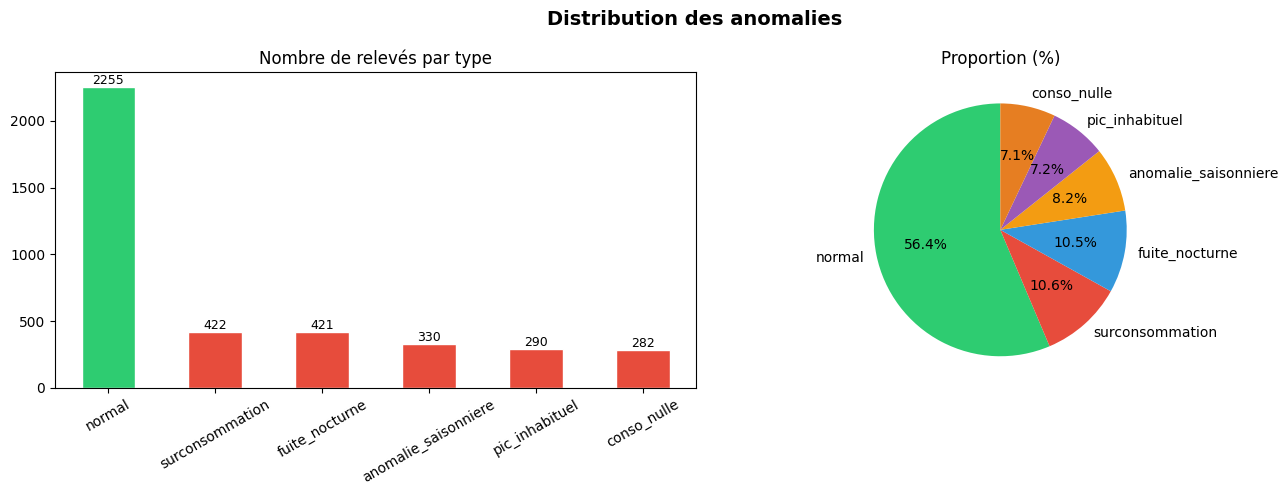

In [9]:
# ─── Graphique 1 : Distribution des anomalies ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribution des anomalies', fontsize=14, fontweight='bold')

counts = df['anomaly_name'].value_counts()
colors = ['#2ecc71' if c == 'normal' else '#e74c3c' for c in counts.index]
ax = counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=9)
axes[0].set_title('Nombre de relevés par type')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

pie_colors = ['#2ecc71','#e74c3c','#3498db','#f39c12','#9b59b6','#e67e22']
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=pie_colors, startangle=90)
axes[1].set_title('Proportion (%)')

plt.tight_layout()
plt.show()


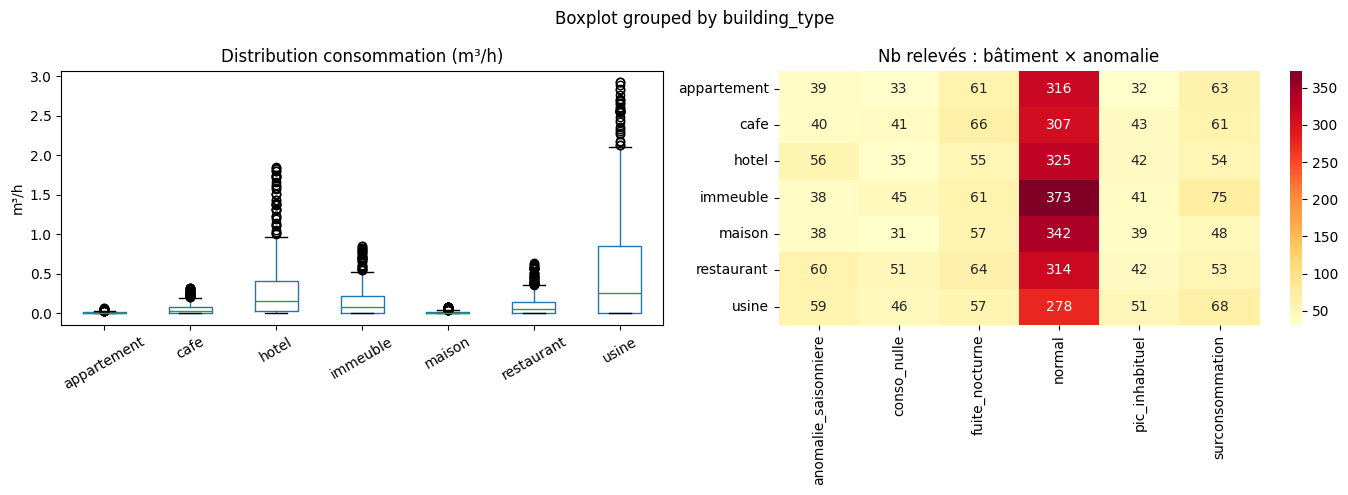

In [10]:
# ─── Graphique 2 : Consommation par type de bâtiment ──────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Consommation par type de bâtiment (m³/h)', fontsize=14, fontweight='bold')

df.boxplot(column='consumption_m3h', by='building_type',
           ax=axes[0], grid=False)
axes[0].set_title('Distribution consommation (m³/h)')
axes[0].set_xlabel('')
axes[0].set_ylabel('m³/h')
axes[0].tick_params(axis='x', rotation=30)
plt.sca(axes[0])
plt.title('Distribution consommation (m³/h)')

pivot = df.groupby(['building_type', 'anomaly_name']).size().unstack(fill_value=0)
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd', ax=axes[1])
axes[1].set_title('Nb relevés : bâtiment × anomalie')
axes[1].set_xlabel('')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


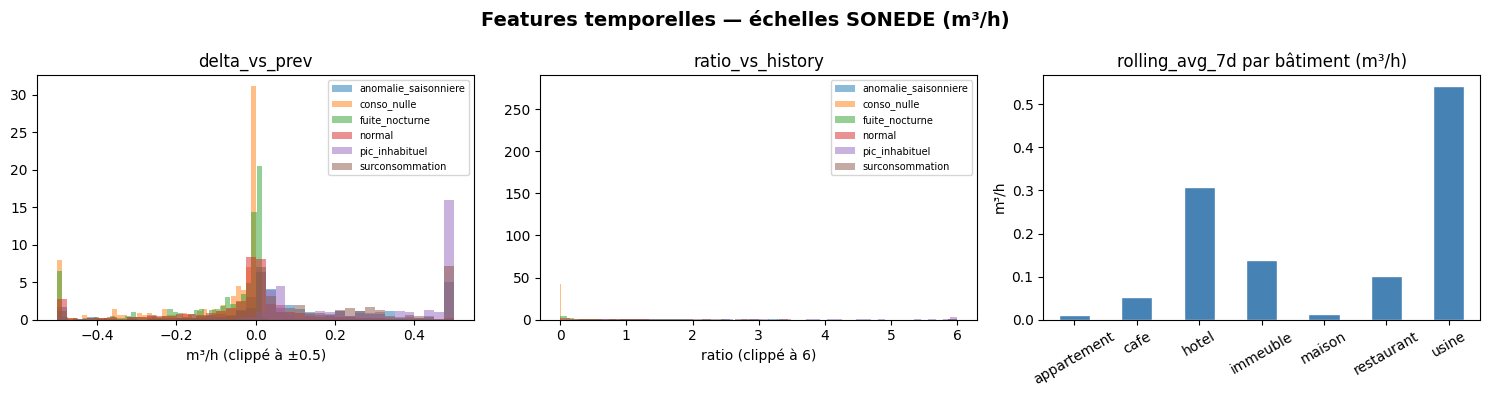

In [11]:
# ─── Graphique 3 : Features temporelles ───────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Features temporelles — échelles SONEDE (m³/h)', fontsize=14, fontweight='bold')

# delta_vs_prev clip adapté à l'échelle réelle (max ~0.6 m³/h pour usine)
for name, grp in df.groupby('anomaly_name'):
    axes[0].hist(grp['delta_vs_prev'].clip(-0.5, 0.5), bins=40,
                 alpha=0.5, label=name, density=True)
axes[0].set_title('delta_vs_prev')
axes[0].set_xlabel('m³/h (clippé à ±0.5)')
axes[0].legend(fontsize=7)

for name, grp in df.groupby('anomaly_name'):
    axes[1].hist(grp['ratio_vs_history'].clip(0, 6), bins=40,
                 alpha=0.5, label=name, density=True)
axes[1].set_title('ratio_vs_history')
axes[1].set_xlabel('ratio (clippé à 6)')
axes[1].legend(fontsize=7)

df.groupby('building_type')['rolling_avg_7d'].mean().plot(
    kind='bar', ax=axes[2], color='steelblue', edgecolor='white')
axes[2].set_title('rolling_avg_7d par bâtiment (m³/h)')
axes[2].set_xlabel('')
axes[2].set_ylabel('m³/h')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


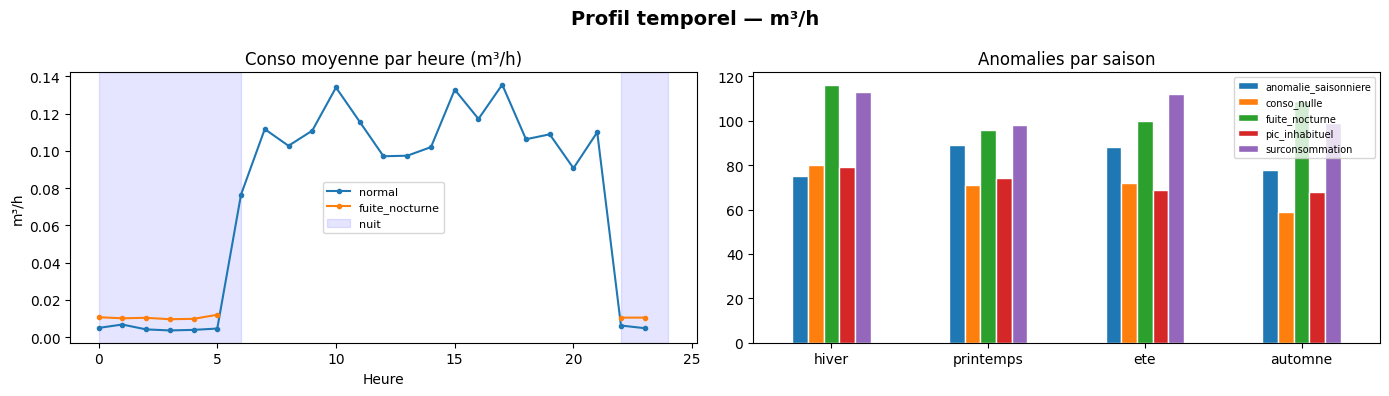

In [12]:
# ─── Graphique 4 : Profil temporel ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Profil temporel — m³/h', fontsize=14, fontweight='bold')

hourly = df.groupby(['hour', 'anomaly_name'])['consumption_m3h'].mean().unstack()
hourly[['normal', 'fuite_nocturne']].plot(ax=axes[0], marker='o', markersize=3)
axes[0].set_title('Conso moyenne par heure (m³/h)')
axes[0].set_xlabel('Heure')
axes[0].set_ylabel('m³/h')
axes[0].axvspan(22, 24, alpha=0.1, color='blue', label='nuit')
axes[0].axvspan(0, 6,  alpha=0.1, color='blue')
axes[0].legend(fontsize=8)

season_order = ['hiver', 'printemps', 'ete', 'automne']
season_anom = df[df['anomaly_name'] != 'normal'].groupby(
    ['season', 'anomaly_name']).size().unstack(fill_value=0)
season_anom = season_anom.reindex(season_order)
season_anom.plot(kind='bar', ax=axes[1], edgecolor='white')
axes[1].set_title('Anomalies par saison')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(fontsize=7, loc='upper right')

plt.tight_layout()
plt.show()


In [13]:
# ─── Sauvegarde du dataset ────────────────────────────────────
CSV_PATH = '/kaggle/working/water_anomaly_dataset.csv'
df.to_csv(CSV_PATH, index=False)
print(f'✅ Dataset sauvegardé : {CSV_PATH}')
print(f'   {len(df)} lignes × {df.shape[1]} colonnes')
print(f'\nColonnes :', list(df.columns))


✅ Dataset sauvegardé : /kaggle/working/water_anomaly_dataset.csv
   4000 lignes × 17 colonnes

Colonnes : ['building_type', 'season', 'hour', 'day_of_week', 'is_night', 'threshold_m3h', 'alert_threshold_m3h', 'consumption_m3h', 'consumption_ratio', 'rolling_avg_7d', 'delta_vs_prev', 'ratio_vs_history', 'over_alert', 'near_zero', 'night_spike', 'anomaly_label', 'anomaly_name']


## 🔧 Étape 4 — Préparation des données

In [14]:
# ─── Encodage des variables catégorielles ─────────────────────
le_building = LabelEncoder()
le_season   = LabelEncoder()

df['building_type_enc'] = le_building.fit_transform(df['building_type'])
df['season_enc']        = le_season.fit_transform(df['season'])

print('Encodage building_type :', dict(zip(
    le_building.classes_, le_building.transform(le_building.classes_))))
print('Encodage season        :', dict(zip(
    le_season.classes_, le_season.transform(le_season.classes_))))

# Colonnes renommées : threshold_m3h / alert_threshold_m3h / consumption_m3h
# (m³/h = unité physique réelle des relevés horaires SONEDE)
FEATURES = [
    'building_type_enc',
    'season_enc',
    'hour',
    'day_of_week',
    'is_night',
    'threshold_m3h',
    'alert_threshold_m3h',
    'consumption_m3h',
    'consumption_ratio',
    'rolling_avg_7d',
    'delta_vs_prev',
    'ratio_vs_history',
    'over_alert',
    'near_zero',
    'night_spike',
]

X = df[FEATURES]
y = df['anomaly_label']
label_names = ANOMALY_NAMES

print(f'\n✅ Features : {len(FEATURES)}')
print(f'   X shape  : {X.shape}')
print(f'   Classes  : {sorted(y.unique())}')


Encodage building_type : {np.str_('appartement'): np.int64(0), np.str_('cafe'): np.int64(1), np.str_('hotel'): np.int64(2), np.str_('immeuble'): np.int64(3), np.str_('maison'): np.int64(4), np.str_('restaurant'): np.int64(5), np.str_('usine'): np.int64(6)}
Encodage season        : {np.str_('automne'): np.int64(0), np.str_('ete'): np.int64(1), np.str_('hiver'): np.int64(2), np.str_('printemps'): np.int64(3)}

✅ Features : 15
   X shape  : (4000, 15)
   Classes  : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


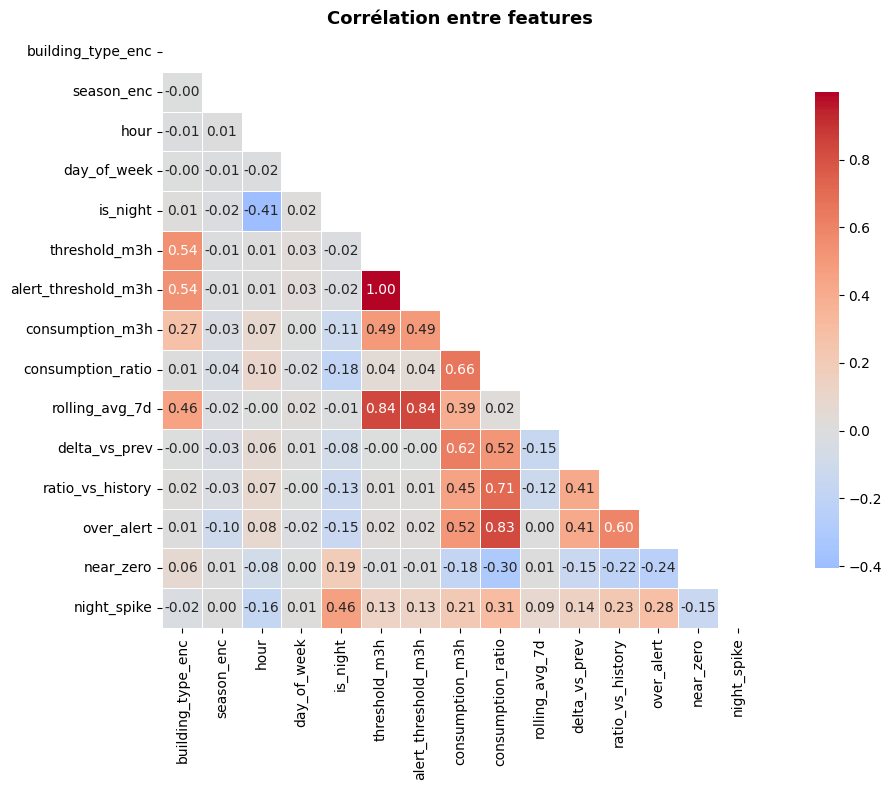

In [15]:
# ─── Corrélation des features ─────────────────────────────────
plt.figure(figsize=(12, 8))
corr = X.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': .8})
plt.title('Corrélation entre features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [16]:
# ─── Split train / test ───────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled  = scaler.transform(X_test)

print(f'Train avant SMOTE  : {X_train.shape[0]} lignes')
print(f'Train après SMOTE  : {X_train_res.shape[0]} lignes')
print(f'Test               : {X_test.shape[0]} lignes')
print(f'\nDistribution après SMOTE :')
print(pd.Series(y_train_res).map(ANOMALY_NAMES).value_counts().to_string())


Train avant SMOTE  : 3200 lignes
Train après SMOTE  : 10824 lignes
Test               : 800 lignes

Distribution après SMOTE :
anomaly_label
normal                  1804
anomalie_saisonniere    1804
conso_nulle             1804
surconsommation         1804
fuite_nocturne          1804
pic_inhabituel          1804


## 🤖 Étape 5 — Entraînement des modèles

In [17]:
# ─── Random Forest ────────────────────────────────────────────
print('⏳ Entraînement Random Forest...')
rf_model = RandomForestClassifier(
    n_estimators=150, max_depth=15,
    class_weight='balanced', random_state=42
)
rf_model.fit(X_train_res, y_train_res)
rf_pred  = rf_model.predict(X_test)
rf_acc   = accuracy_score(y_test, rf_pred)
rf_f1    = f1_score(y_test, rf_pred, average='weighted')
print(f'✅ Random Forest  — Accuracy: {rf_acc:.4f} | F1: {rf_f1:.4f}')


⏳ Entraînement Random Forest...
✅ Random Forest  — Accuracy: 0.8850 | F1: 0.8872


In [18]:
# ─── XGBoost ──────────────────────────────────────────────────
print('⏳ Entraînement XGBoost...')
xgb_model = XGBClassifier(
    n_estimators=200, max_depth=6,
    learning_rate=0.1, subsample=0.8,
    eval_metric='mlogloss', random_state=42
    # ✅ use_label_encoder supprimé (paramètre obsolète depuis XGBoost 1.6)
)
xgb_model.fit(X_train_res, y_train_res)
xgb_pred = xgb_model.predict(X_test)
xgb_acc  = accuracy_score(y_test, xgb_pred)
xgb_f1   = f1_score(y_test, xgb_pred, average='weighted')
print(f'✅ XGBoost         — Accuracy: {xgb_acc:.4f} | F1: {xgb_f1:.4f}')


⏳ Entraînement XGBoost...
✅ XGBoost         — Accuracy: 0.9038 | F1: 0.9040


In [19]:
# ─── MLP (réseau de neurones) ─────────────────────────────────
print('⏳ Entraînement MLP...')
mlp_model = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu', max_iter=300,
    early_stopping=True, random_state=42
)
mlp_model.fit(X_train_scaled, y_train_res)
mlp_pred = mlp_model.predict(X_test_scaled)
mlp_acc  = accuracy_score(y_test, mlp_pred)
mlp_f1   = f1_score(y_test, mlp_pred, average='weighted')
print(f'✅ MLP             — Accuracy: {mlp_acc:.4f} | F1: {mlp_f1:.4f}')


⏳ Entraînement MLP...
✅ MLP             — Accuracy: 0.8200 | F1: 0.8241


In [20]:
# ─── Isolation Forest (non-supervisé, bonus) ──────────────────
print('⏳ Entraînement Isolation Forest (non-supervisé)...')
X_normal = X_train_res[y_train_res == 0]
iso_model = IsolationForest(
    n_estimators=200, contamination=0.15,
    random_state=42
)
iso_model.fit(X_normal)
iso_raw  = iso_model.predict(X_test)
iso_bin  = (iso_raw == -1).astype(int)
y_bin    = (y_test > 0).astype(int)
iso_acc  = accuracy_score(y_bin, iso_bin)
iso_f1   = f1_score(y_bin, iso_bin, average='binary')
print(f'✅ Isolation Forest— Accuracy: {iso_acc:.4f} | F1 (binaire): {iso_f1:.4f}')
print('   (détecte anomalie vs normal, ne classe pas le type)')


⏳ Entraînement Isolation Forest (non-supervisé)...
✅ Isolation Forest— Accuracy: 0.7312 | F1 (binaire): 0.6504
   (détecte anomalie vs normal, ne classe pas le type)


## 📈 Étape 6 — Comparaison des modèles

In [21]:
# ─── Tableau comparatif ───────────────────────────────────────
results = pd.DataFrame([
    {'Modèle': 'Random Forest', 'Accuracy': rf_acc,  'F1 weighted': rf_f1,  'Type': 'Supervisé'},
    {'Modèle': 'XGBoost',       'Accuracy': xgb_acc, 'F1 weighted': xgb_f1, 'Type': 'Supervisé'},
    {'Modèle': 'MLP',           'Accuracy': mlp_acc, 'F1 weighted': mlp_f1, 'Type': 'Supervisé'},
    {'Modèle': 'Isolation Forest','Accuracy': iso_acc,'F1 weighted': iso_f1, 'Type': 'Non-supervisé (binaire)'},
]).sort_values('F1 weighted', ascending=False).reset_index(drop=True)

print('\n' + '═'*60)
print('COMPARAISON DES MODÈLES'.center(60))
print('═'*60)
print(results.to_string(index=False))
print('═'*60)

best_name = results.iloc[0]['Modèle']
print(f'\n🏆 Meilleur modèle : {best_name}')



════════════════════════════════════════════════════════════
                  COMPARAISON DES MODÈLES                   
════════════════════════════════════════════════════════════
          Modèle  Accuracy  F1 weighted                    Type
         XGBoost   0.90375     0.904049               Supervisé
   Random Forest   0.88500     0.887187               Supervisé
             MLP   0.82000     0.824082               Supervisé
Isolation Forest   0.73125     0.650407 Non-supervisé (binaire)
════════════════════════════════════════════════════════════

🏆 Meilleur modèle : XGBoost


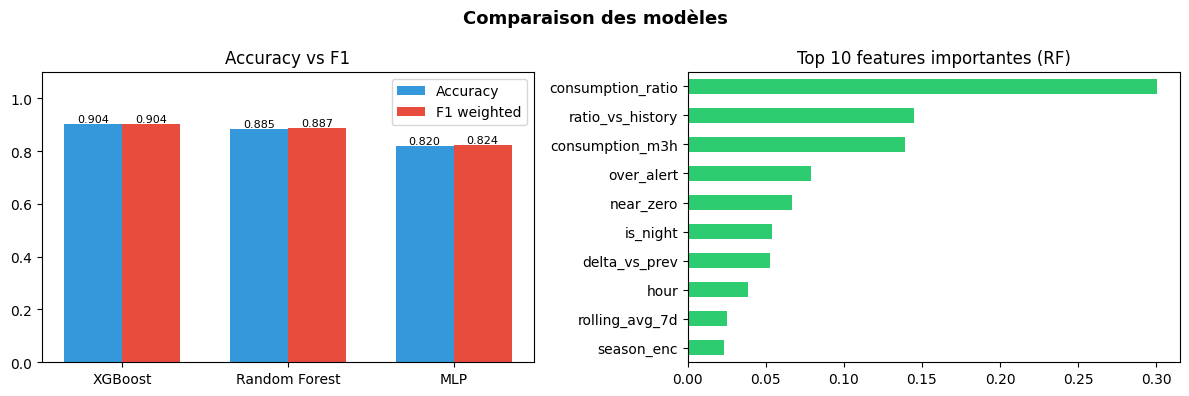

In [22]:
# ─── Graphique comparatif ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Comparaison des modèles', fontsize=13, fontweight='bold')

sup_results = results[results['Type'] == 'Supervisé']

x = np.arange(len(sup_results))
w = 0.35
axes[0].bar(x - w/2, sup_results['Accuracy'], w, label='Accuracy', color='#3498db')
axes[0].bar(x + w/2, sup_results['F1 weighted'], w, label='F1 weighted', color='#e74c3c')
axes[0].set_xticks(x)
axes[0].set_xticklabels(sup_results['Modèle'])
axes[0].set_ylim(0, 1.1)
axes[0].legend()
axes[0].set_title('Accuracy vs F1')
for bar in axes[0].patches:
    axes[0].annotate(f'{bar.get_height():.3f}',
                (bar.get_x() + bar.get_width()/2., bar.get_height()),
                ha='center', va='bottom', fontsize=8)

fi = pd.Series(rf_model.feature_importances_, index=FEATURES)
fi.sort_values().tail(10).plot(kind='barh', ax=axes[1], color='#2ecc71')
axes[1].set_title('Top 10 features importantes (RF)')

plt.tight_layout()
plt.show()


In [23]:
# ─── Sélection du meilleur modèle & rapport détaillé ─────────
MODELS = {
    'Random Forest' : (rf_model,  X_test,        rf_pred),
    'XGBoost'       : (xgb_model, X_test,        xgb_pred),
    'MLP'           : (mlp_model, X_test_scaled, mlp_pred),
}
best_name = results[results['Type']=='Supervisé'].iloc[0]['Modèle']
best_model, best_X, best_pred = MODELS[best_name]

print(f'🏆 Meilleur modèle : {best_name}')
print('\nRapport de classification :')
print(classification_report(
    y_test, best_pred,
    target_names=[ANOMALY_NAMES[i] for i in sorted(ANOMALY_NAMES)]))


🏆 Meilleur modèle : XGBoost

Rapport de classification :
                      precision    recall  f1-score   support

              normal       0.96      0.93      0.95       451
     surconsommation       0.78      0.86      0.82        85
      fuite_nocturne       0.87      0.93      0.90        84
anomalie_saisonniere       0.63      0.61      0.62        66
         conso_nulle       0.96      0.96      0.96        56
      pic_inhabituel       0.97      0.98      0.97        58

            accuracy                           0.90       800
           macro avg       0.86      0.88      0.87       800
        weighted avg       0.91      0.90      0.90       800



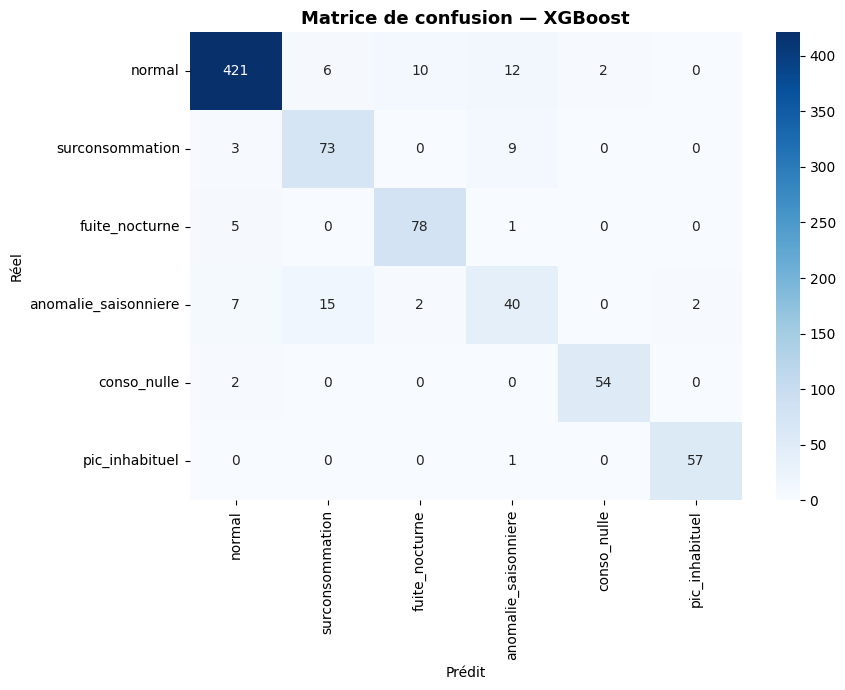

In [24]:
# ─── Matrice de confusion ─────────────────────────────────────
cm = confusion_matrix(y_test, best_pred)
class_names = [ANOMALY_NAMES[i] for i in sorted(ANOMALY_NAMES)]

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Matrice de confusion — {best_name}', fontsize=13, fontweight='bold')
plt.ylabel('Réel')
plt.xlabel('Prédit')
plt.tight_layout()
plt.show()


## 💾 Sauvegarde du modèle

In [25]:
# ─── Sauvegarde ───────────────────────────────────────────────
SAVE_DIR = '/kaggle/working/anomaly_model'
os.makedirs(SAVE_DIR, exist_ok=True)

joblib.dump(best_model,  f'{SAVE_DIR}/best_model.pkl')
joblib.dump(scaler,      f'{SAVE_DIR}/scaler.pkl')
joblib.dump(le_building, f'{SAVE_DIR}/le_building.pkl')
joblib.dump(le_season,   f'{SAVE_DIR}/le_season.pkl')

metadata = {
    'model_name'      : best_name,
    'features'        : FEATURES,
    'label_names'     : {str(k): v for k, v in ANOMALY_NAMES.items()},
    'thresholds'      : THRESHOLDS,
    'alert_thresholds': ALERT_THRESHOLDS,
    'season_coefs'    : SEASON_COEF,
    'night_ratios'    : NIGHT_RATIO,
    'leak_min_m3h'    : LEAK_MIN,
    'leak_max_m3h'    : LEAK_MAX,
    'sonede_notes'    : {
        'unit'            : 'm3_per_hour',
        'maison_ref_m3h'  : THRESHOLDS['maison'],
        'alert_m3_quarter': 40,
        'summer_factor'   : SEASON_COEF['ete'],
        'source'          : 'SONEDE Rapport Annuel 2023',
    },
    'accuracy'        : round(float(accuracy_score(y_test, best_pred)), 4),
    'f1_weighted'     : round(float(f1_score(y_test, best_pred,
                                             average='weighted')), 4),
}
with open(f'{SAVE_DIR}/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print('✅ Modèle sauvegardé dans :', SAVE_DIR)
print('   Fichiers :', os.listdir(SAVE_DIR))
print(f'\nÉchelles SONEDE enregistrées :')
print(f'   Unité          : m³/heure')
print(f'   Maison réf.    : {THRESHOLDS["maison"]} m³/h  ({THRESHOLDS["maison"]*1000:.0f} L/h)')
print(f'   Alerte SONEDE  : {ALERT_THRESHOLDS["maison"]} m³/h  (≡ 40 m³/trimestre)')
print(f'   Coeff. été     : ×{SEASON_COEF["ete"]}  (stress hydrique tunisien)')


✅ Modèle sauvegardé dans : /kaggle/working/anomaly_model
   Fichiers : ['metadata.json', 'le_season.pkl', 'best_model.pkl', 'scaler.pkl', 'le_building.pkl']

Échelles SONEDE enregistrées :
   Unité          : m³/heure
   Maison réf.    : 0.013 m³/h  (13 L/h)
   Alerte SONEDE  : 0.018 m³/h  (≡ 40 m³/trimestre)
   Coeff. été     : ×2.0  (stress hydrique tunisien)


## 📦 Étape 7 — Export ZIP pour téléchargement

Zippe tous les fichiers du modèle pour les télécharger facilement depuis l'onglet **Output** de Kaggle.

In [26]:
# ─── ZIP du modèle pour téléchargement ───────────────────────
import shutil

zip_path = '/kaggle/working/anomaly_model_export'
shutil.make_archive(zip_path, 'zip', '/kaggle/working/anomaly_model')

zip_size = os.path.getsize(zip_path + '.zip') / 1024
print(f'✅ ZIP créé : {zip_path}.zip')
print(f'   Taille  : {zip_size:.1f} KB')
print(f'   Contenu : {os.listdir(SAVE_DIR)}')
print()
print('📥 Pour télécharger :')
print('   → Onglet Output (panneau droit) → anomaly_model_export.zip → ⬇')


✅ ZIP créé : /kaggle/working/anomaly_model_export.zip
   Taille  : 659.0 KB
   Contenu : ['metadata.json', 'le_season.pkl', 'best_model.pkl', 'scaler.pkl', 'le_building.pkl']

📥 Pour télécharger :
   → Onglet Output (panneau droit) → anomaly_model_export.zip → ⬇


## 🩺 Étape 8 — Diagnostic interactif

> **Mode d'emploi** : modifie les valeurs en haut, exécute la cellule.

In [27]:
# ╔══════════════════════════════════════════════════════════════╗
# ║    DIAGNOSTIC COMPTEUR D'EAU — ÉCHELLES SONEDE 2023          ║
# ║    Unités : m³/heure  (relevé horaire)                        ║
# ║    Modifie les valeurs ci-dessous puis exécute la cellule     ║
# ╚══════════════════════════════════════════════════════════════╝

BUILDING   = 'maison'    # maison | appartement | cafe | restaurant | hotel | immeuble | usine
SEASON     = 'ete'       # hiver | printemps | ete | automne
HOUR       = 3           # 0–23
DAY        = 1           # 0=lundi … 6=dimanche

# ── Valeur lue sur le compteur (m³/heure) ──────────────────────
# Exemples réalistes SONEDE :
#   0.013  → maison normale (pic diurne)
#   0.002  → maison la nuit (quasi nul)
#   0.006  → fuite nocturne (robinet qui goutte ~6 L/h)
#   0.040  → surconsommation maison (dépasse seuil alerte 40 m³/trim)
CONSO      = 0.006       # ← valeur lue par le compteur (m³/h)
PREV_CONSO = 0.013       # ← relevé horaire précédent (m³/h)
HIST_AVG   = 0.011       # ← moyenne 7 jours glissants (m³/h)
# ──────────────────────────────────────────────────────────────

SAVE_DIR = '/kaggle/working/anomaly_model'

model  = joblib.load(f'{SAVE_DIR}/best_model.pkl')
le_b   = joblib.load(f'{SAVE_DIR}/le_building.pkl')
le_s   = joblib.load(f'{SAVE_DIR}/le_season.pkl')
with open(f'{SAVE_DIR}/metadata.json') as f:
    meta = json.load(f)

THR   = meta['thresholds'][BUILDING]
ALERT = meta['alert_thresholds'][BUILDING]
FEAT  = meta['features']
LBLS  = {int(k): v for k, v in meta['label_names'].items()}
LEAK_MAX_STORED = meta.get('leak_max_m3h', 0.012)

is_night    = 1 if (HOUR >= 22 or HOUR <= 5) else 0
ratio       = CONSO / THR if THR > 0 else 0
over_alert  = 1 if CONSO > ALERT else 0
near_zero   = 1 if CONSO < THR * 0.005 else 0
# night_spike : flux nocturne > 1.5× seuil fuite max connue
night_spike = 1 if (is_night == 1 and CONSO > LEAK_MAX_STORED * 1.5) else 0
delta       = CONSO - PREV_CONSO
ratio_hist  = CONSO / HIST_AVG if HIST_AVG > 0 else 0

row = pd.DataFrame([{
    'building_type_enc' : le_b.transform([BUILDING])[0],
    'season_enc'        : le_s.transform([SEASON])[0],
    'hour'              : HOUR,
    'day_of_week'       : DAY,
    'is_night'          : is_night,
    'threshold_m3h'     : THR,
    'alert_threshold_m3h': ALERT,
    'consumption_m3h'   : CONSO,
    'consumption_ratio' : ratio,
    'rolling_avg_7d'    : HIST_AVG,
    'delta_vs_prev'     : delta,
    'ratio_vs_history'  : ratio_hist,
    'over_alert'        : over_alert,
    'near_zero'         : near_zero,
    'night_spike'       : night_spike,
}])[FEAT]

pred_label = int(model.predict(row)[0])
pred_proba = model.predict_proba(row)[0]
pred_name  = LBLS[pred_label]
confidence = round(float(pred_proba[pred_label]) * 100, 1)

ICONS = {
    'normal'              : '✅',
    'surconsommation'     : '🚨',
    'fuite_nocturne'      : '💧',
    'anomalie_saisonniere': '🌡️',
    'conso_nulle'         : '⛔',
    'pic_inhabituel'      : '⚡',
}
MSGS = {
    'normal'              : 'Consommation normale — aucune action requise.',
    'surconsommation'     : f'Dépasse seuil alerte SONEDE (≡ 40 m³/trimestre) !',
    'fuite_nocturne'      : f'Fuite détectée ({CONSO*1000:.1f} L/h) — vérifier joints et canalisations.',
    'anomalie_saisonniere': 'Profil incompatible avec la saison — anomalie tarifaire possible.',
    'conso_nulle'         : 'Compteur bloqué ou coupure réseau SONEDE ?',
    'pic_inhabituel'      : 'Pic suspect — possible rupture de canalisation ou usage illicite.',
}

W = 60
print('╔' + '═'*W + '╗')
print('║' + ' DIAGNOSTIC COMPTEUR D\'EAU — SONEDE 2023 '.center(W) + '║')
print('╠' + '═'*W + '╣')
print(f'║  Bâtiment         : {BUILDING:<{W-21}}║')
print(f'║  Saison           : {SEASON:<{W-21}}║')
print(f'║  Heure            : {str(HOUR)+"h":<{W-21}}║')
print(f'║  Consommation     : {str(CONSO)+" m³/h  ("+str(round(CONSO*1000,1))+" L/h)":<{W-21}}║')
print(f'║  Seuil normal     : {str(THR)+" m³/h":<{W-21}}║')
print(f'║  Seuil alerte     : {str(ALERT)+" m³/h  (≡ 40 m³/trim)":<{W-21}}║')
print(f'║  Delta/précédent  : {str(round(delta,5))+" m³/h":<{W-21}}║')
print(f'║  Ratio historique : {str(round(ratio_hist,2))+"x":<{W-21}}║')
print('╠' + '═'*W + '╣')
icon = ICONS.get(pred_name, '❓')
res_line = f'{icon}  {pred_name.upper()}'
print(f'║  {res_line:<{W-2}}║')
print(f'║  Confiance        : {str(confidence)+"%":<{W-21}}║')
print(f'║  {MSGS[pred_name]:<{W-2}}║')
print('╠' + '═'*W + '╣')
print('║  Probabilités :' + ' '*(W-16) + '║')
for i, prob in enumerate(pred_proba):
    name = LBLS[i]
    pct  = round(prob * 100, 1)
    bar  = '█' * int(pct / 5)
    line = f'  {name:<24} {pct:5.1f}%  {bar}'
    print(f'║{line:<{W}}║')
print('╚' + '═'*W + '╝')


╔════════════════════════════════════════════════════════════╗
║          DIAGNOSTIC COMPTEUR D'EAU — SONEDE 2023           ║
╠════════════════════════════════════════════════════════════╣
║  Bâtiment         : maison                                 ║
║  Saison           : ete                                    ║
║  Heure            : 3h                                     ║
║  Consommation     : 0.006 m³/h  (6.0 L/h)                  ║
║  Seuil normal     : 0.013 m³/h                             ║
║  Seuil alerte     : 0.018 m³/h  (≡ 40 m³/trim)             ║
║  Delta/précédent  : -0.007 m³/h                            ║
║  Ratio historique : 0.55x                                  ║
╠════════════════════════════════════════════════════════════╣
║  💧  FUITE_NOCTURNE                                         ║
║  Confiance        : 100.0%                                 ║
║  Fuite détectée (6.0 L/h) — vérifier joints et canalisations.║
╠════════════════════════════════════════════════════